In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import (
    StandardScaler
)

from sklearn.model_selection import (
    train_test_split
)

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader
)

from tqdm import tqdm

In [2]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)
print(device)

cuda


In [3]:
df = pd.read_csv(
    "FINAL_DATA.csv"
)

In [4]:
SAT_COLUMN = "Satellite_ID"

TIME_COLUMN = "Timestamp"

df[TIME_COLUMN] = pd.to_datetime(
    df[TIME_COLUMN]
)

df = df.sort_values(
    [SAT_COLUMN, TIME_COLUMN]
).reset_index(drop=True)

In [5]:
from sklearn.preprocessing import LabelEncoder

sat_encoder = LabelEncoder()

df["sat_idx"] = sat_encoder.fit_transform(
    df[SAT_COLUMN]
)

In [6]:
df["hour"] = df[TIME_COLUMN].dt.hour

df["minute"] = df[TIME_COLUMN].dt.minute

df["time_minutes"] = (
    df["hour"] * 60
    +
    df["minute"]
)

df["time_sin"] = np.sin(

    2 * np.pi *

    df["time_minutes"]

    / 1440
)

df["time_cos"] = np.cos(

    2 * np.pi *

    df["time_minutes"]

    / 1440
)

In [7]:
ROLL_WINDOW = 8

for col in [

    "Error_X",
    "Error_Y",
    "Error_Z",
    "Error_Clock"

]:

    df[f"{col}_roll_mean"] = (

        df.groupby(SAT_COLUMN)[col]

        .transform(

            lambda x:

            x.rolling(
                ROLL_WINDOW,
                min_periods=1
            ).mean()
        )
    )

In [8]:
TARGET_COLUMNS = [

    "Error_X",
    "Error_Y",
    "Error_Z",
    "Error_Clock"
]

FEATURE_COLUMNS = [

    "Error_X",
    "Error_Y",
    "Error_Z",
    "Error_Clock",

    "time_sin",
    "time_cos",

    "Error_X_roll_mean",
    "Error_Y_roll_mean",
    "Error_Z_roll_mean",
    "Error_Clock_roll_mean"
]

In [9]:
feature_scaler = StandardScaler()

target_scaler = StandardScaler()

df[FEATURE_COLUMNS] = (
    feature_scaler.fit_transform(
        df[FEATURE_COLUMNS]
    )
)

df[TARGET_COLUMNS] = (
    target_scaler.fit_transform(
        df[TARGET_COLUMNS]
    )
)


In [10]:
INPUT_WINDOW = 96
FORECAST_HORIZON = 96

X = []
Y = []
SAT = []
SPIKE = []

spike_threshold = 1.5

for sat_id in df["sat_idx"].unique():

    sat_df = df[
        df["sat_idx"] == sat_id
    ]

    feature_values = sat_df[
        FEATURE_COLUMNS
    ].values

    target_values = sat_df[
        TARGET_COLUMNS
    ].values

    for i in range(

        len(sat_df)

        -

        INPUT_WINDOW

        -

        FORECAST_HORIZON
    ):

        x_seq = feature_values[
            i :
            i + INPUT_WINDOW
        ]

        y_seq = target_values[
            i + INPUT_WINDOW :

            i + INPUT_WINDOW
            +
            FORECAST_HORIZON
        ]

        spike_labels = (

            np.abs(y_seq)

            > spike_threshold

        ).any(axis=1).astype(np.float32)

        X.append(x_seq)

        Y.append(y_seq)

        SAT.append(sat_id)

        SPIKE.append(spike_labels)

X = np.array(X)

Y = np.array(Y)

SAT = np.array(SAT)

SPIKE = np.array(SPIKE)

In [11]:
print(X.shape)
print(Y.shape)
print(SPIKE.shape)

(30653, 96, 10)
(30653, 96, 4)
(30653, 96)


In [12]:
(
    X_train,
    X_temp,

    Y_train,
    Y_temp,

    SAT_train,
    SAT_temp,

    SPIKE_train,
    SPIKE_temp

) = train_test_split(

    X,
    Y,

    SAT,

    SPIKE,

    test_size=0.3,

    shuffle=False
)

(
    X_val,
    X_test,

    Y_val,
    Y_test,

    SAT_val,
    SAT_test,

    SPIKE_val,
    SPIKE_test

) = train_test_split(

    X_temp,
    Y_temp,

    SAT_temp,

    SPIKE_temp,

    test_size=0.5,

    shuffle=False
)

In [13]:
class GNSSDataset(Dataset):

    def __init__(

        self,

        X,
        Y,

        SAT,
        SPIKE
    ):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.Y = torch.tensor(
            Y,
            dtype=torch.float32
        )

        self.SAT = torch.tensor(
            SAT,
            dtype=torch.long
        )

        self.SPIKE = torch.tensor(
            SPIKE,
            dtype=torch.float32
        )

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        return (

            self.X[idx],

            self.Y[idx],

            self.SAT[idx],

            self.SPIKE[idx]
        )

In [14]:
train_dataset = GNSSDataset(

    X_train,
    Y_train,

    SAT_train,

    SPIKE_train
)

val_dataset = GNSSDataset(

    X_val,
    Y_val,

    SAT_val,

    SPIKE_val
)

test_dataset = GNSSDataset(

    X_test,
    Y_test,

    SAT_test,

    SPIKE_test
)

In [15]:
train_loader = DataLoader(

    train_dataset,

    batch_size=32,

    shuffle=True
)

val_loader = DataLoader(

    val_dataset,

    batch_size=32,

    shuffle=False
)

test_loader = DataLoader(

    test_dataset,

    batch_size=32,

    shuffle=False
)

In [16]:
x, y, sat, spike = next(
    iter(train_loader)
)

print(x.shape)
print(y.shape)
print(sat.shape)
print(spike.shape)

print(sat.dtype)
print(spike.dtype)

torch.Size([32, 96, 10])
torch.Size([32, 96, 4])
torch.Size([32])
torch.Size([32, 96])
torch.int64
torch.float32


In [17]:
class PositionalEncoding(nn.Module):

    def __init__(
        self,
        d_model,
        max_len=500
    ):

        super().__init__()

        pe = torch.zeros(
            max_len,
            d_model
        )

        position = torch.arange(
            0,
            max_len
        ).unsqueeze(1)

        div_term = torch.exp(

            torch.arange(
                0,
                d_model,
                2
            )

            *

            (-np.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(
            position * div_term
        )

        pe[:, 1::2] = torch.cos(
            position * div_term
        )

        pe = pe.unsqueeze(0)

        self.register_buffer(
            "pe",
            pe
        )

    def forward(self, x):

        x = x + self.pe[:, :x.size(1)]

        return x

In [18]:
class GNSSTransformerBackbone(nn.Module):

    def __init__(

        self,

        num_features,
        num_satellites,

        d_model=64,

        embedding_dim=8,

        nhead=4,

        num_layers=3,

        dropout=0.1
    ):

        super().__init__()

        self.d_model = d_model

        # Satellite embeddings
        self.sat_embedding = nn.Embedding(

            num_satellites,

            embedding_dim
        )

        # Input projection
        self.input_projection = nn.Linear(

            num_features + embedding_dim,

            d_model
        )

        # Positional encoding
        self.positional_encoding = (
            PositionalEncoding(d_model)
        )

        # Transformer encoder
        encoder_layer = (
            nn.TransformerEncoderLayer(

                d_model=d_model,

                nhead=nhead,

                batch_first=True,

                dropout=dropout
            )
        )

        self.transformer = (
            nn.TransformerEncoder(

                encoder_layer,

                num_layers=num_layers
            )
        )

    def forward(

        self,

        x,
        sat_ids
    ):

        batch_size, seq_len, _ = x.shape

        # Satellite embedding
        sat_embed = self.sat_embedding(
            sat_ids
        )

        sat_embed = sat_embed.unsqueeze(1).repeat(

            1,
            seq_len,
            1
        )

        # Concatenate features
        x = torch.cat(

            [x, sat_embed],

            dim=-1
        )

        # Project
        x = self.input_projection(x)

        # Positional encoding
        x = self.positional_encoding(x)

        # Transformer encoder
        x = self.transformer(x)

        return x

In [19]:
backbone = GNSSTransformerBackbone(

    num_features=len(FEATURE_COLUMNS),

    num_satellites=len(
        np.unique(SAT)
    )

).to(device)

In [20]:
x, y, sat, spike = next(
    iter(train_loader)
)

x = x.to(device)

sat = sat.to(device)

with torch.no_grad():

    latent = backbone(
        x,
        sat
    )

print(latent.shape)

torch.Size([32, 96, 64])


In [21]:
class ContextAggregator(nn.Module):

    def __init__(

        self,

        d_model=64
    ):

        super().__init__()

        self.attention = nn.Sequential(

            nn.Linear(d_model, 64),

            nn.Tanh(),

            nn.Linear(64, 1)
        )

    def forward(
        self,
        x
    ):

        # x shape:
        # (batch, seq, d_model)

        weights = self.attention(x)

        weights = torch.softmax(
            weights,
            dim=1
        )

        context = torch.sum(

            weights * x,

            dim=1
        )

        return context

In [22]:
aggregator = ContextAggregator().to(device)

with torch.no_grad():

    context = aggregator(latent)

print(context.shape)

torch.Size([32, 64])


In [23]:
class FutureDecoder(nn.Module):

    def __init__(

        self,

        d_model=64,

        forecast_horizon=96
    ):

        super().__init__()

        self.future_queries = nn.Parameter(

            torch.randn(

                1,

                forecast_horizon,

                d_model
            )
        )

    def forward(
        self,
        context
    ):

        batch_size = context.size(0)

        context = context.unsqueeze(1)

        future_queries = self.future_queries.repeat(

            batch_size,

            1,

            1
        )

        decoder_input = (

            future_queries

            +

            context
        )

        return decoder_input

In [24]:
future_decoder = FutureDecoder().to(device)

with torch.no_grad():

    decoder_input = future_decoder(
        context
    )

print(decoder_input.shape)

torch.Size([32, 96, 64])


In [25]:
class ProbabilisticHead(nn.Module):

    def __init__(

        self,

        d_model=64,

        output_dim=4
    ):

        super().__init__()

        self.network = nn.Sequential(

            nn.LayerNorm(d_model),

            nn.Linear(d_model, 128),

            nn.GELU(),

            nn.Dropout(0.1),

            nn.Linear(
                128,
                output_dim * 2
            )
        )

        self.output_dim = output_dim

    def forward(
        self,
        x
    ):

        out = self.network(x)

        mu = out[:, :, :self.output_dim]

        sigma = torch.clamp(

            F.softplus(

                out[:, :, self.output_dim:]
            ),

            min=0.05,

            max=2.0
        )

        return mu, sigma

In [26]:
class SpikeHead(nn.Module):

    def __init__(
        self,
        d_model=64
    ):

        super().__init__()

        self.network = nn.Sequential(

            nn.LayerNorm(d_model),

            nn.Linear(d_model, 64),

            nn.GELU(),

            nn.Linear(64, 1)
        )

    def forward(
        self,
        x
    ):

        logits = self.network(x)

        probs = torch.sigmoid(
            logits
        )

        return probs.squeeze(-1)

In [27]:
class GNSSForecaster(nn.Module):

    def __init__(

        self,

        num_features,
        num_satellites,

        d_model=64,

        forecast_horizon=96,

        output_dim=4
    ):

        super().__init__()

        self.backbone = (
            GNSSTransformerBackbone(

                num_features=num_features,

                num_satellites=num_satellites,

                d_model=d_model
            )
        )

        self.aggregator = (
            ContextAggregator(
                d_model=d_model
            )
        )

        self.future_decoder = (
            FutureDecoder(

                d_model=d_model,

                forecast_horizon=forecast_horizon
            )
        )

        self.prob_head = (
            ProbabilisticHead(

                d_model=d_model,

                output_dim=output_dim
            )
        )

        self.spike_head = (
            SpikeHead(
                d_model=d_model
            )
        )

    def forward(

        self,

        x,
        sat_ids
    ):

        # Backbone latent sequence
        latent = self.backbone(
            x,
            sat_ids
        )

        # Global context
        context = self.aggregator(
            latent
        )

        # Future latent tokens
        decoder_input = (
            self.future_decoder(
                context
            )
        )

        # Spike probabilities
        spike_probs = self.spike_head(
            decoder_input
        )

        # Event conditioning
        spike_context = (
            spike_probs.unsqueeze(-1)
        )

        decoder_input = (

            decoder_input

            *

            (

                1

                +

                0.25 * spike_context
            )
        )

        # Probabilistic outputs
        mu, sigma = self.prob_head(
            decoder_input
        )

        return (

            mu,
            sigma,
            spike_probs,
            context
        )

In [28]:
model = GNSSForecaster(

    num_features=len(
        FEATURE_COLUMNS
    ),

    num_satellites=len(
        np.unique(SAT)
    )

).to(device)

In [29]:
x, y, sat, spike = next(
    iter(train_loader)
)

x = x.to(device)

sat = sat.to(device)

with torch.no_grad():

    mu, sigma, spike_probs, context = model(

        x,
        sat
    )

print(mu.shape)

print(sigma.shape)

print(spike_probs.shape)

print(context.shape)

torch.Size([32, 96, 4])
torch.Size([32, 96, 4])
torch.Size([32, 96])
torch.Size([32, 64])


In [30]:
def gaussian_nll_loss(

    mu,
    sigma,

    targets
):

    loss = (

        torch.log(sigma)

        +

        ((targets - mu) ** 2)

        /

        (2 * sigma ** 2)
    )

    return loss.mean()
bce_loss = nn.BCELoss()

def spike_loss(

    spike_probs,

    spike_targets
):

    return bce_loss(

        spike_probs,

        spike_targets
    )

def smoothness_loss(predictions):

    diffs = (

        predictions[:, 1:, :]

        -

        predictions[:, :-1, :]
    )

    return torch.mean(
        diffs ** 2
    )

def multiscale_smoothness_loss(

    predictions
):

    total_loss = 0

    scales = [1, 2, 4, 8]

    for scale in scales:

        diffs = (

            predictions[:, scale:, :]

            -

            predictions[:, :-scale, :]
        )

        total_loss += torch.mean(
            diffs ** 2
        )

    return total_loss

def frequency_loss(

    predictions,

    targets
):

    pred_fft = torch.fft.rfft(

        predictions,

        dim=1
    )

    target_fft = torch.fft.rfft(

        targets,

        dim=1
    )

    pred_mag = torch.abs(
        pred_fft
    )

    target_mag = torch.abs(
        target_fft
    )

    return torch.mean(

        (pred_mag - target_mag) ** 2
    )

def clock_drift_loss(predictions):

    clock = predictions[:, :, 3]

    velocity = (

        clock[:, 1:]

        -

        clock[:, :-1]
    )

    acceleration = (

        velocity[:, 1:]

        -

        velocity[:, :-1]
    )

    return torch.mean(
        acceleration ** 2
    )



In [31]:
def total_loss(

    mu,
    sigma,

    spike_probs,

    targets,
    spike_targets,

    lambda_smooth=0.02,

    lambda_multi=0.02,

    lambda_freq=0.02,

    lambda_clock=0.01,

    lambda_spike=0.1,

    lambda_sigma=0.01
):

    # Probabilistic forecasting
    nll = gaussian_nll_loss(

        mu,
        sigma,

        targets
    )

    # Event prediction
    spike = spike_loss(

        spike_probs,

        spike_targets
    )

    # Temporal smoothness
    smooth = smoothness_loss(mu)

    # Multi-scale continuity
    multi = multiscale_smoothness_loss(
        mu
    )

    # Frequency consistency
    freq = frequency_loss(

        mu,
        targets
    )

    # Clock continuity
    clock = clock_drift_loss(mu)

    # Prevent sigma explosion
    sigma_penalty = (

        1.0 / sigma.mean()
    )

    total = (

        nll

        +

        lambda_spike * spike

        +

        lambda_smooth * smooth

        +

        lambda_multi * multi

        +

        lambda_freq * freq

        +

        lambda_clock * clock

        +

        lambda_sigma * sigma_penalty
    )

    return total

In [32]:
optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=1e-5
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=0.5,

    patience=3
)

In [33]:
def train_one_epoch(

    model,

    loader,

    optimizer
):

    model.train()

    total_epoch_loss = 0

    for x, y, sat, spike_targets in tqdm(loader):

        x = x.to(device)

        y = y.to(device)

        sat = sat.to(device)

        spike_targets = spike_targets.to(device)

        optimizer.zero_grad()

        mu, sigma, spike_probs, context = model(

            x,
            sat
        )

        loss = total_loss(

            mu,
            sigma,

            spike_probs,

            y,
            spike_targets
        )

        loss.backward()

        # IMPORTANT
        # Prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            max_norm=1.0
        )

        optimizer.step()

        total_epoch_loss += loss.item()

    return total_epoch_loss / len(loader)

In [34]:
def validate(

    model,

    loader
):

    model.eval()

    total_loss_val = 0

    sigma_means = []

    spike_means = []

    with torch.no_grad():

        for x, y, sat, spike_targets in loader:

            x = x.to(device)

            y = y.to(device)

            sat = sat.to(device)

            spike_targets = spike_targets.to(device)

            mu, sigma, spike_probs, context = model(

                x,
                sat
            )

            loss = total_loss(

                mu,
                sigma,

                spike_probs,

                y,
                spike_targets
            )

            total_loss_val += loss.item()

            sigma_means.append(

                sigma.mean().item()
            )

            spike_means.append(

                spike_probs.mean().item()
            )

    avg_loss = total_loss_val / len(loader)

    avg_sigma = np.mean(sigma_means)

    avg_spike = np.mean(spike_means)

    return (

        avg_loss,

        avg_sigma,

        avg_spike
    )

In [35]:
EPOCHS = 30

train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(

        model,

        train_loader,

        optimizer
    )

    val_loss, sigma_mean, spike_mean = validate(

        model,

        val_loader
    )

    scheduler.step(val_loss)

    train_losses.append(train_loss)

    val_losses.append(val_loss)

    print(

        f"Epoch {epoch+1}"

        f" | Train Loss: {train_loss:.6f}"

        f" | Val Loss: {val_loss:.6f}"

        f" | Sigma Mean: {sigma_mean:.4f}"

        f" | Spike Mean: {spike_mean:.4f}"
    )

100%|████████████████████████████████████████████████████████████████████████████████| 671/671 [00:18<00:00, 35.73it/s]


Epoch 1 | Train Loss: 2.741293 | Val Loss: 0.326212 | Sigma Mean: 0.7207 | Spike Mean: 0.1094


100%|████████████████████████████████████████████████████████████████████████████████| 671/671 [00:17<00:00, 37.36it/s]


Epoch 2 | Train Loss: 1.860636 | Val Loss: 0.328268 | Sigma Mean: 0.6962 | Spike Mean: 0.0852


100%|████████████████████████████████████████████████████████████████████████████████| 671/671 [00:17<00:00, 37.43it/s]


...

Epoch 28 | Train Loss: 0.395160 | Val Loss: 0.349094 | Sigma Mean: 0.6023 | Spike Mean: 0.0878


100%|████████████████████████████████████████████████████████████████████████████████| 671/671 [00:17<00:00, 37.58it/s]


Epoch 29 | Train Loss: 0.394059 | Val Loss: 0.435276 | Sigma Mean: 0.6009 | Spike Mean: 0.0871


100%|████████████████████████████████████████████████████████████████████████████████| 671/671 [00:19<00:00, 35.27it/s]


Epoch 30 | Train Loss: 0.393467 | Val Loss: 0.424107 | Sigma Mean: 0.6020 | Spike Mean: 0.0879


In [36]:
model.eval()

mu_list = []
sigma_list = []

target_list = []

spike_prob_list = []

with torch.no_grad():

    
    for x, y, sat, spike_targets in val_loader:

        x = x.to(device)

        sat = sat.to(device)

        mu, sigma, spike_probs, context = model(

            x,
            sat
        )

        mu_list.append(
            mu.cpu().numpy()
        )

        sigma_list.append(
            sigma.cpu().numpy()
        )

        target_list.append(
            y.numpy()
        )

        spike_prob_list.append(
            spike_probs.cpu().numpy()
        )

In [37]:
mu = np.concatenate(
    mu_list,
    axis=0
)


sigma = np.concatenate(
    sigma_list,
    axis=0
)

targets = np.concatenate(
    target_list,
    axis=0
)

spike_probs = np.concatenate(
    spike_prob_list,
    axis=0
)

In [38]:
mu_flat = mu.reshape(-1, 4)

target_flat = targets.reshape(-1, 4)

mu_real = target_scaler.inverse_transform(
    mu_flat
)

target_real = target_scaler.inverse_transform(
    target_flat
)

mu_real = mu_real.reshape(mu.shape)

target_real = target_real.reshape(
    targets.shape
)

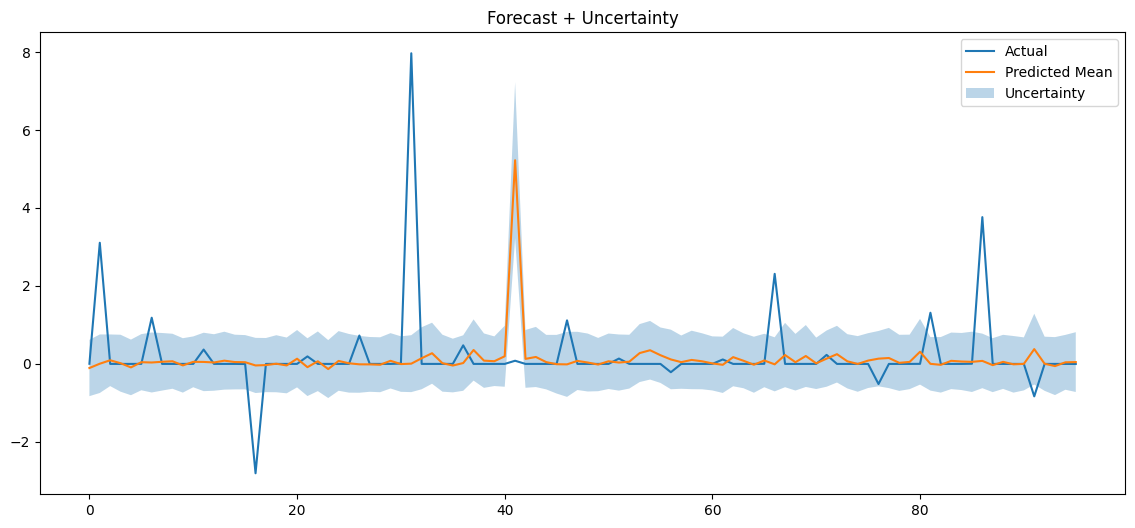

In [39]:
sample_idx = 0

feature_idx = 0

plt.figure(figsize=(14,6))

plt.plot(

    target_real[sample_idx, :, feature_idx],

    label="Actual"
)

plt.plot(

    mu_real[sample_idx, :, feature_idx],

    label="Predicted Mean"
)

upper = (

    mu_real[sample_idx, :, feature_idx]

    +

    sigma[sample_idx, :, feature_idx]
)

lower = (

    mu_real[sample_idx, :, feature_idx]

    -

    sigma[sample_idx, :, feature_idx]
)

plt.fill_between(

    np.arange(len(upper)),

    lower,

    upper,

    alpha=0.3,

    label="Uncertainty"
)

plt.legend()

plt.title("Forecast + Uncertainty")

plt.show()

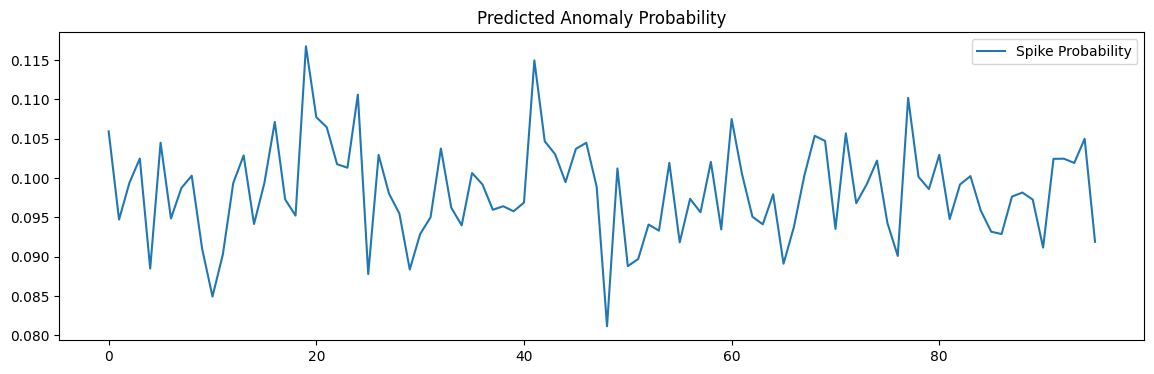

In [40]:
plt.figure(figsize=(14,4))

plt.plot(

    spike_probs[sample_idx],

    label="Spike Probability"
)

plt.title("Predicted Anomaly Probability")

plt.legend()

plt.show()

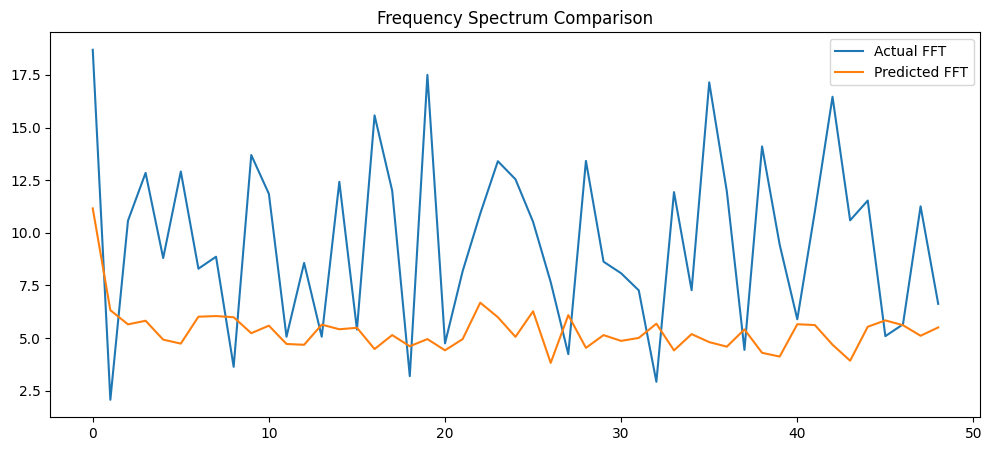

In [41]:
actual_fft = np.abs(

    np.fft.rfft(

        target_real[sample_idx, :, feature_idx]
    )
)

pred_fft = np.abs(

    np.fft.rfft(

        mu_real[sample_idx, :, feature_idx]
    )
)

plt.figure(figsize=(12,5))

plt.plot(

    actual_fft,

    label="Actual FFT"
)

plt.plot(

    pred_fft,

    label="Predicted FFT"
)

plt.legend()

plt.title("Frequency Spectrum Comparison")

plt.show()

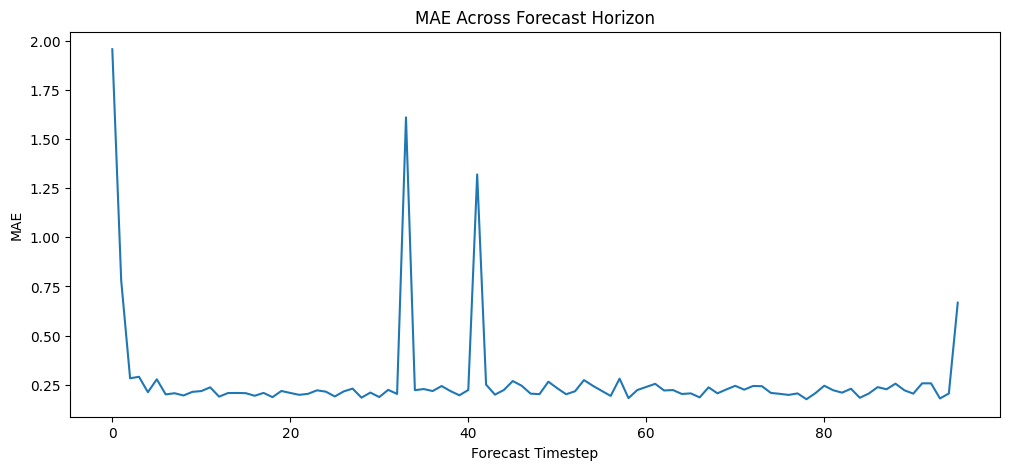

In [42]:
mae_per_timestep = np.mean(

    np.abs(

        mu_real - target_real
    ),

    axis=(0,2)
)

plt.figure(figsize=(12,5))

plt.plot(mae_per_timestep)

plt.title("MAE Across Forecast Horizon")

plt.xlabel("Forecast Timestep")

plt.ylabel("MAE")

plt.show()

In [43]:
DIFFUSION_STEPS = 100

BETA_START = 1e-4

BETA_END = 0.02

In [44]:
betas = torch.linspace(

    BETA_START,

    BETA_END,

    DIFFUSION_STEPS

).to(device)

alphas = 1.0 - betas

alpha_bars = torch.cumprod(

    alphas,

    dim=0
)

In [45]:
def diffusion_loss(

    predicted_noise,

    true_noise
):

    return F.mse_loss(

        predicted_noise,

        true_noise
    )

In [46]:
def forward_diffusion_sample(

    x0,

    t
):

    noise = torch.randn_like(x0)

    sqrt_alpha_bar = torch.sqrt(

        alpha_bars[t]

    ).view(-1,1,1)

    sqrt_one_minus = torch.sqrt(

        1 - alpha_bars[t]

    ).view(-1,1,1)

    noisy_x = (

        sqrt_alpha_bar * x0

        +

        sqrt_one_minus * noise
    )

    return noisy_x, noise

In [47]:
class DiffusionTimeEmbedding(nn.Module):

    def __init__(

        self,

        d_model=64
    ):

        super().__init__()

        self.embedding = nn.Embedding(

            DIFFUSION_STEPS,

            d_model
        )

    def forward(
        self,
        t
    ):

        return self.embedding(t)

In [48]:
class ConditionalDiffusionDenoiser(nn.Module):

    def __init__(

        self,

        d_model=64,

        output_dim=4,

        num_layers=2,

        nhead=4
    ):

        super().__init__()

        self.time_embedding = (
            DiffusionTimeEmbedding(
                d_model
            )
        )

        self.input_projection = nn.Linear(

            output_dim,

            d_model
        )

        self.positional_encoding = (
            PositionalEncoding(
                d_model
            )
        )

        encoder_layer = (
            nn.TransformerEncoderLayer(

                d_model=d_model,

                nhead=nhead,

                batch_first=True
            )
        )

        self.transformer = (
            nn.TransformerEncoder(

                encoder_layer,

                num_layers=num_layers
            )
        )

        self.output_projection = nn.Linear(

            d_model,

            output_dim
        )

    def forward(

        self,

        noisy_future,

        context,

        t
    ):

        x = self.input_projection(
            noisy_future
        )

        t_embed = self.time_embedding(t)

        t_embed = t_embed.unsqueeze(1)

        x = x + t_embed

        context = context.unsqueeze(1)

        x = x + context

        x = self.positional_encoding(x)

        x = self.transformer(x)

        predicted_noise = (
            self.output_projection(x)
        )

        return predicted_noise

In [49]:
diffusion_model = (

    ConditionalDiffusionDenoiser(

        d_model=64,

        output_dim=4
    )

).to(device)

In [50]:
x, y, sat, spike = next(
    iter(train_loader)
)

x = x.to(device)

y = y.to(device)

sat = sat.to(device)

with torch.no_grad():

    mu, sigma, spike_probs, context = model(

        x,
        sat
    )

    batch_size = y.shape[0]

    t = torch.randint(

        0,

        DIFFUSION_STEPS,

        (batch_size,),

        device=device
    )

    noisy_y, noise = (

        forward_diffusion_sample(
            y,
            t
        )
    )

    pred_noise = diffusion_model(

        noisy_y,

        context,

        t
    )

print(pred_noise.shape)

torch.Size([32, 96, 4])


In [51]:
diffusion_optimizer = torch.optim.AdamW(

    diffusion_model.parameters(),

    lr=1e-5,

    weight_decay=1e-5
)

In [52]:
def train_diffusion_epoch(

    forecaster,

    diffusion_model,

    loader,

    optimizer
):

    diffusion_model.train()

    total_epoch_loss = 0

    for x, y, sat, spike in tqdm(loader):

        x = x.to(device)

        y = y.to(device)

        sat = sat.to(device)

        batch_size = y.shape[0]

        # IMPORTANT
        # Freeze forecaster
        with torch.no_grad():

            mu, sigma, spike_probs, context = forecaster(

                x,
                sat
            )

        # Random diffusion timesteps
        t = torch.randint(

            0,

            DIFFUSION_STEPS,

            (batch_size,),

            device=device
        )

        # Add noise
        # Residual target
        residual = y - mu

        # Diffuse residuals
        noisy_residual, true_noise = (

            forward_diffusion_sample(

                residual,
                t
            )
        )

        optimizer.zero_grad()

        # Predict noise
        predicted_noise = diffusion_model(

            noisy_residual,

            context,

            t
        )

        loss = diffusion_loss(

            predicted_noise,

            true_noise
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(

            diffusion_model.parameters(),

            1.0
        )

        optimizer.step()

        total_epoch_loss += loss.item()

    return total_epoch_loss / len(loader)

In [53]:
DIFFUSION_EPOCHS = 80

diffusion_losses = []

for epoch in range(DIFFUSION_EPOCHS):

    loss = train_diffusion_epoch(

        model,

        diffusion_model,

        train_loader,

        diffusion_optimizer
    )

    diffusion_losses.append(loss)

    print(

        f"Diffusion Epoch {epoch+1}"

        f" | Loss: {loss:.6f}"
    )

100%|████████████████████████████████████████████████████████████████████████████████| 671/671 [00:16<00:00, 41.81it/s]


Diffusion Epoch 1 | Loss: 0.780135


100%|████████████████████████████████████████████████████████████████████████████████| 671/671 [00:16<00:00, 41.30it/s]


Diffusion Epoch 2 | Loss: 0.579842


100%|████████████████████████████████████████████████████████████████████████████████| 671/671 [00:16<00:00, 41.52it/s]


...

Diffusion Epoch 78 | Loss: 0.266861


100%|████████████████████████████████████████████████████████████████████████████████| 671/671 [00:15<00:00, 42.18it/s]


Diffusion Epoch 79 | Loss: 0.265551


100%|████████████████████████████████████████████████████████████████████████████████| 671/671 [00:15<00:00, 42.15it/s]

Diffusion Epoch 80 | Loss: 0.265368


In [54]:
@torch.no_grad()

def sample_diffusion(

    diffusion_model,

    context,

    mu,

    shape,

    noise_scale=0.1
):

    diffusion_model.eval()

    # IMPORTANT:
    # Start from coarse transformer forecast
    noise = torch.randn(shape).to(device)

    x = mu + noise_scale * noise

    for step in reversed(

        range(DIFFUSION_STEPS)
    ):

        t = torch.full(

            (shape[0],),

            step,

            device=device,

            dtype=torch.long
        )

        predicted_noise = diffusion_model(

            x,

            context,

            t
        )

        alpha = alphas[step]

        alpha_bar = alpha_bars[step]

        beta = betas[step]

        x = (

            1 / torch.sqrt(alpha)

        ) * (

            x

            -

            (

                (1 - alpha)

                /

                torch.sqrt(
                    1 - alpha_bar
                )

            )

            *

            predicted_noise
        )

        # Small stochastic refinement
        if step > 0:

            extra_noise = torch.randn_like(x)

            x = (

                x

                +

                torch.sqrt(beta)

                *

                0.1

                *

                extra_noise
            )

    return mu + x

In [55]:
x, y, sat, spike = next(
    iter(val_loader)
)

x = x.to(device)

sat = sat.to(device)

with torch.no_grad():

    mu, sigma, spike_probs, context = model(

        x,
        sat
    )

generated_future = sample_diffusion(

    diffusion_model,

    context,

    mu,

    shape=y.shape
)

In [56]:
generated_future = (

    generated_future

    .cpu()

    .numpy()
)

real_future = y.numpy()

In [57]:
gen_flat = generated_future.reshape(-1,4)

real_flat = real_future.reshape(-1,4)

gen_real = target_scaler.inverse_transform(
    gen_flat
)

real_real = target_scaler.inverse_transform(
    real_flat
)

gen_real = gen_real.reshape(
    generated_future.shape
)

real_real = real_real.reshape(
    real_future.shape
)

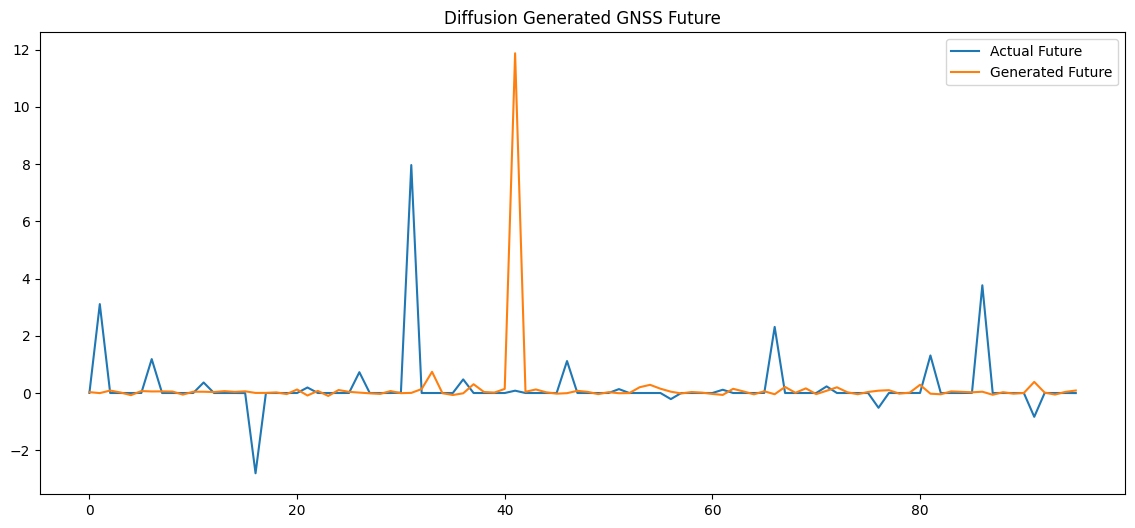

In [58]:
sample_idx = 0

feature_idx = 0

plt.figure(figsize=(14,6))

plt.plot(

    real_real[sample_idx,:,feature_idx],

    label="Actual Future"
)

plt.plot(

    gen_real[sample_idx,:,feature_idx],

    label="Generated Future"
)

plt.legend()

plt.title(

    "Diffusion Generated GNSS Future"
)

plt.show()

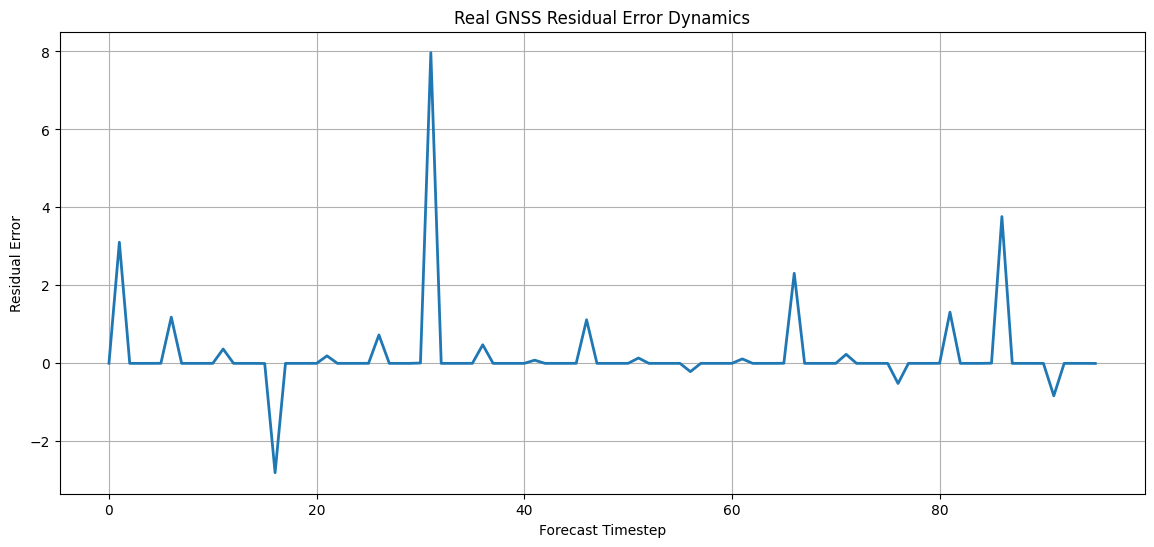

In [59]:
sample_idx = 0
feature_idx = 0

plt.figure(figsize=(14,6))

plt.plot(

    target_real[sample_idx,:,feature_idx],

    linewidth=2
)

plt.title(

    "Real GNSS Residual Error Dynamics"
)

plt.xlabel("Forecast Timestep")

plt.ylabel("Residual Error")

plt.grid(True)

plt.show()

NameError: name 'sigma_real' is not defined

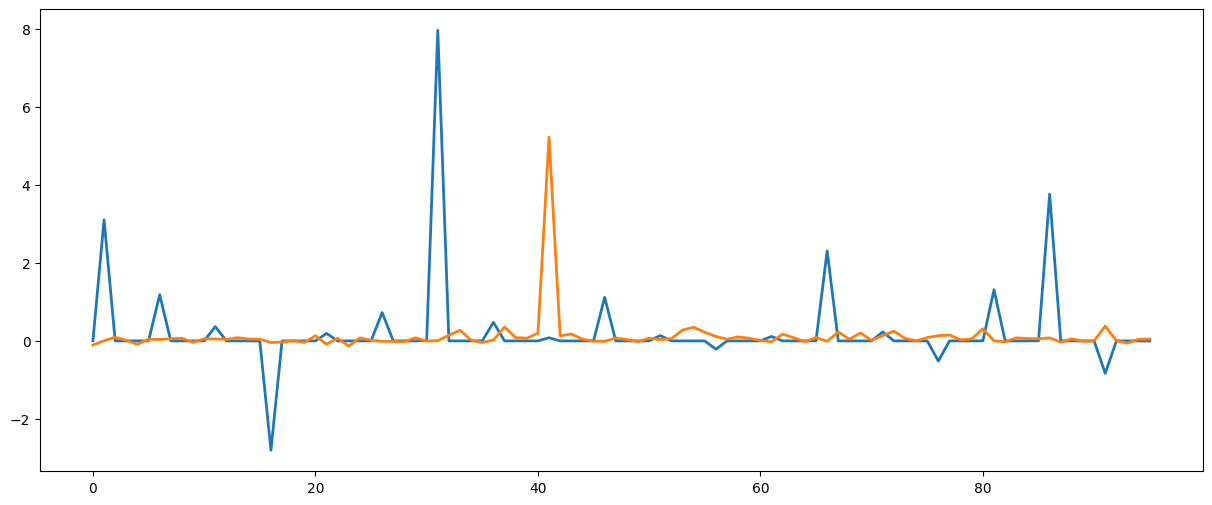

In [60]:
sample_idx = 0
feature_idx = 0

plt.figure(figsize=(15,6))

plt.plot(

    target_real[sample_idx,:,feature_idx],

    label="Actual",

    linewidth=2
)

plt.plot(

    mu_real[sample_idx,:,feature_idx],

    label="Predicted Mean",

    linewidth=2
)

upper = (

    mu_real[sample_idx,:,feature_idx]

    +

    sigma_real[sample_idx,:,feature_idx]
)

lower = (

    mu_real[sample_idx,:,feature_idx]

    -

    sigma_real[sample_idx,:,feature_idx]
)

plt.fill_between(

    np.arange(len(upper)),

    lower,

    upper,

    alpha=0.3,

    label="Uncertainty"
)

plt.title(

    "Probabilistic GNSS Forecasting"
)

plt.xlabel("Forecast Timestep")

plt.ylabel("Residual Error")

plt.legend()

plt.grid(True)

plt.show()

NameError: name 'train_mae_history' is not defined

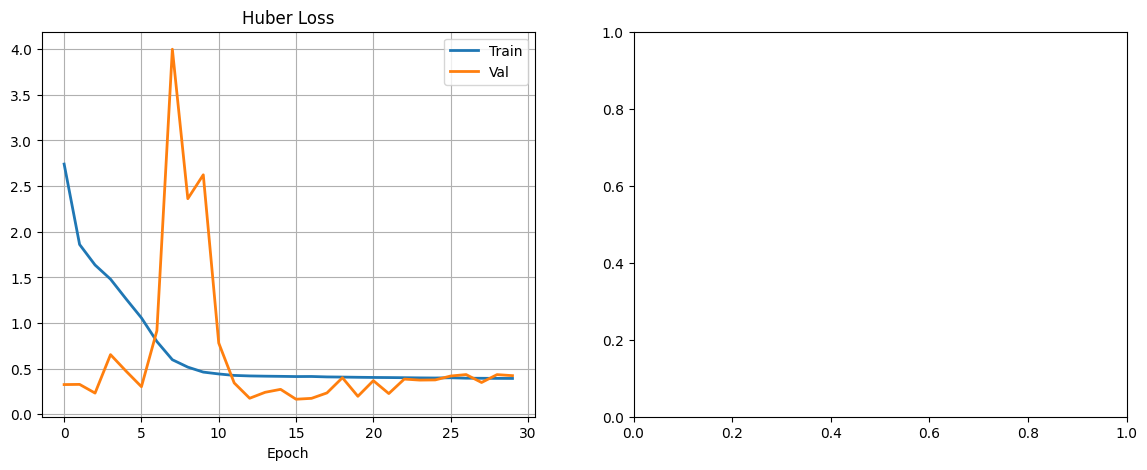

In [62]:
fig, axes = plt.subplots(

    1,
    2,

    figsize=(14,5)
)

# Huber Loss
axes[0].plot(

    train_losses,

    label="Train",

    linewidth=2
)

axes[0].plot(

    val_losses,

    label="Val",

    linewidth=2
)

axes[0].set_title("Huber Loss")

axes[0].set_xlabel("Epoch")

axes[0].legend()

axes[0].grid(True)

# MAE
axes[1].plot(

    train_mae_history,

    label="Train",

    linewidth=2
)

axes[1].plot(

    val_mae_history,

    label="Val",

    linewidth=2
)

axes[1].set_title("MAE")

axes[1].set_xlabel("Epoch")

axes[1].legend()

axes[1].grid(True)

plt.suptitle(

    "Training History",

    fontsize=20,

    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [ ]:
actual_fft = np.abs(

    np.fft.rfft(

        target_real[sample_idx,:,feature_idx]
    )
)

pred_fft = np.abs(

    np.fft.rfft(

        mu_real[sample_idx,:,feature_idx]
    )
)

plt.figure(figsize=(14,5))

plt.plot(

    actual_fft,

    label="Actual FFT",

    linewidth=2
)

plt.plot(

    pred_fft,

    label="Predicted FFT",

    linewidth=2
)

plt.title(

    "Frequency Spectrum Consistency"
)

plt.xlabel("Frequency Bin")

plt.ylabel("Magnitude")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
mae_per_timestep = np.mean(

    np.abs(

        mu_real - target_real
    ),

    axis=(0,2)
)

plt.figure(figsize=(14,5))

plt.plot(

    mae_per_timestep,

    linewidth=2
)

plt.title(

    "MAE Across Forecast Horizon"
)

plt.xlabel("Forecast Timestep")

plt.ylabel("MAE")

plt.grid(True)

plt.show()

In [ ]:
sample_idx = 0
feature_idx = 0

plt.figure(figsize=(15,6))

plt.plot(

    real_real[sample_idx,:,feature_idx],

    label="Actual Future",

    linewidth=2
)

plt.plot(

    gen_real[sample_idx,:,feature_idx],

    label="Generated Future",

    linewidth=2
)

plt.title(

    "Diffusion Generated GNSS Future"
)

plt.xlabel("Forecast Timestep")

plt.ylabel("Residual Error")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
sample_idx = 0
feature_idx = 0

plt.figure(figsize=(15,6))

plt.plot(

    real_real[sample_idx,:,feature_idx],

    color="black",

    linewidth=3,

    label="Actual"
)

for i in range(20):

    generated = sample_diffusion(

        diffusion_model,

        context,

        mu,

        shape=y.shape,

        noise_scale=0.03
    )

    generated = generated.cpu().numpy()

    gen_flat = generated.reshape(-1,4)

    gen_real_multi = target_scaler.inverse_transform(
        gen_flat
    )

    gen_real_multi = gen_real_multi.reshape(
        generated.shape
    )

    plt.plot(

        gen_real_multi[sample_idx,:,feature_idx],

        alpha=0.25
    )

plt.title(

    "Multi-Sample GNSS Future Generation"
)

plt.xlabel("Forecast Timestep")

plt.ylabel("Residual Error")

plt.grid(True)

plt.show()

In [ ]:
sample_idx = 0
feature_idx = 0

horizons = {

    "15 min": 1,
    "30 min": 2,
    "1 hour": 4,
    "3 hour": 12,
    "6 hour": 24,
    "12 hour": 48,
    "24 hour": 96
}

plt.figure(figsize=(16,7))

actual = target_real[
    sample_idx,
    :,
    feature_idx
]

plt.plot(

    actual,

    label="Actual",

    linewidth=3,

    color="black"
)

for label, horizon in horizons.items():

    pred = mu_real[
        sample_idx,
        :horizon,
        feature_idx
    ]

    plt.plot(

        np.arange(horizon),

        pred,

        linewidth=2,

        label=label
    )

plt.title(

    "Multi-Horizon GNSS Forecasting"
)

plt.xlabel("Forecast Timestep")

plt.ylabel("Residual Error")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:

HORIZON_MAP = {

    "15 min": 1,
    "30 min": 2,
    "1 hour": 4,
    "2 hour": 8,
    "6 hour": 24,
    "12 hour": 48,
    "24 hour": 95
}

print(HORIZON_MAP)


In [ ]:

horizon_metrics = {}

for horizon_name, idx in HORIZON_MAP.items():

    pred = mu_real[:, idx, :]

    target = target_real[:, idx, :]

    mae = np.mean(
        np.abs(pred - target)
    )

    rmse = np.sqrt(
        np.mean((pred - target) ** 2)
    )

    horizon_metrics[horizon_name] = {

        "MAE": mae,

        "RMSE": rmse
    }

    print(

        f"{horizon_name}"

        f" | MAE: {mae:.4f}"

        f" | RMSE: {rmse:.4f}"
    )


In [ ]:

sample_idx = 0
feature_idx = 0

plt.figure(figsize=(16,7))

actual = target_real[
    sample_idx,
    :,
    feature_idx
]

plt.plot(

    actual,

    linewidth=3,

    color="black",

    label="Actual"
)

colors = [

    "blue",
    "green",
    "orange",
    "red",
    "purple",
    "brown",
    "cyan"
]

for color, (label, idx) in zip(

    colors,

    HORIZON_MAP.items()
):

    pred_point = mu_real[
        sample_idx,
        idx,
        feature_idx
    ]

    plt.scatter(

        idx,

        pred_point,

        s=120,

        color=color,

        label=label
    )

plt.title(

    "GNSS Predictions at Official Forecast Horizons"
)

plt.xlabel("Forecast Timestep")

plt.ylabel("Residual Error")

plt.legend()

plt.grid(True)

plt.show()


In [ ]:

import seaborn as sns

feature_names = [

    "Error_X",
    "Error_Y",
    "Error_Z",
    "Clock_Error"
]

heatmap_data = []

for feature_idx in range(4):

    row = []

    for _, idx in HORIZON_MAP.items():

        mae = np.mean(

            np.abs(

                mu_real[:, idx, feature_idx]

                -

                target_real[:, idx, feature_idx]
            )
        )

        row.append(mae)

    heatmap_data.append(row)

heatmap_data = np.array(heatmap_data)

plt.figure(figsize=(12,5))

sns.heatmap(

    heatmap_data,

    annot=True,

    cmap="viridis",

    xticklabels=list(HORIZON_MAP.keys()),

    yticklabels=feature_names
)

plt.title(

    "MAE Heatmap Across Official Forecast Horizons"
)

plt.xlabel("Forecast Horizon")

plt.ylabel("Residual Component")

plt.show()


In [ ]:

labels = []
maes = []

for horizon_name, metrics in horizon_metrics.items():

    labels.append(horizon_name)

    maes.append(metrics["MAE"])

plt.figure(figsize=(12,5))

plt.bar(

    labels,

    maes
)

plt.title(

    "Forecast Error Across Official Horizons"
)

plt.xlabel("Forecast Horizon")

plt.ylabel("MAE")

plt.grid(True)

plt.show()


In [ ]:

uncertainties = []

for _, idx in HORIZON_MAP.items():

    unc = np.mean(

        sigma_real[:, idx, :]
    )

    uncertainties.append(unc)

plt.figure(figsize=(12,5))

plt.plot(

    list(HORIZON_MAP.keys()),

    uncertainties,

    marker="o",

    linewidth=3
)

plt.title(

    "Forecast Uncertainty Across Horizons"
)

plt.xlabel("Forecast Horizon")

plt.ylabel("Average Sigma")

plt.grid(True)

plt.show()
